# Consumer Price Index Supervised Machine Learning Predictive Model

## Problem Statement:Create a predictive model that can predict Consumer Price Index.

In [61]:
import pandas as pd
import numpy as np
Consumer_Price_Index_Data=pd.read_excel("C:/Users/Ankit Raut/Python IVY Feb-2024 (2)/Python IVY Feb-2024/My ML Projects/Regression projects/Consumer Price Index/Consumer_Price_Index_in_Denver.xlsx")

print(Consumer_Price_Index_Data.shape)
Consumer_Price_Index_Data.drop_duplicates()
print(Consumer_Price_Index_Data.shape)
Consumer_Price_Index_Data.head(5)

(4349, 17)
(4349, 17)


,stateFips,area,areaType,period,periodYear,periodType,periodTypeDescription,cpi,title,type,source,cpiSourceDescription,percentChangeYear,percentChangeMonth,dataRegion,areaName,areaDescription
0,0,0,0,0,1913,1,Annual,9.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",0.0,0.0,US,United States,The United States of America (commonly referre...
1,0,0,0,0,1913,1,Annual,10.0,"CPI-W all items 1982-84=100, not seasonally ad...",3,1,"US DOL, Bureau of Labor Statistics",0.0,0.0,US,United States,The United States of America (commonly referre...
2,0,0,0,1,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",0.0,-1.0,US,United States,The United States of America (commonly referre...
3,0,0,0,1,1913,3,Monthly,9.9,"CPI-W all items 1982-84=100, not seasonally ad...",3,1,"US DOL, Bureau of Labor Statistics",0.0,-1.0,US,United States,The United States of America (commonly referre...
4,0,0,0,2,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,1,"US DOL, Bureau of Labor Statistics",0.0,0.0,US,United States,The United States of America (commonly referre...


In [62]:
pd.set_option('display.max_rows',None)

In [63]:
Consumer_Price_Index_Data['periodType'].unique()

array([1, 3, 7])

In [64]:
Consumer_Price_Index_Data[(Consumer_Price_Index_Data['areaDescription']=='The United States of America (commonly referred to as the United States, the U.S., the USA, or America) is a federal constitutional republic comprising fifty states and a federal district. The country is situated mostly in central North America, where its forty-eight contiguous states and Washington, D.C., the capital district, lie between the Pacific and Atlantic Oceans, bordered by Canada to the north and Mexico to the south. The state of Alaska is in the northwest of the continent, with Canada to its east and Russia to the west across the Bering Strait. The state of Hawaii is an archipelago in the mid-Pacific. The country also possesses several territories in the Caribbean and Pacific.')].shape

(4095, 17)

In [65]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['areaDescription']=='The United States of America (commonly referred to as the United States, the U.S., the USA, or America) is a federal constitutional republic comprising fifty states and a federal district. The country is situated mostly in central North America, where its forty-eight contiguous states and Washington, D.C., the capital district, lie between the Pacific and Atlantic Oceans, bordered by Canada to the north and Mexico to the south. The state of Alaska is in the northwest of the continent, with Canada to its east and Russia to the west across the Bering Strait. The state of Hawaii is an archipelago in the mid-Pacific. The country also possesses several territories in the Caribbean and Pacific.','areaDescription']='The United States of America'

In [66]:
Consumer_Price_Index_Data.groupby('areaDescription').size()

areaDescription
Denver CPI region                254
The United States of America    4095
dtype: int64

### Not useful columns:Eliminate :'period', 'cpiSourceDescription','source','areaDescription','dataRegion'

In [67]:
Consumer_Price_Index_Data.drop(['period', 'cpiSourceDescription','source','dataRegion'],axis=1,inplace=True)

In [68]:
Consumer_Price_Index_Data.head()

,stateFips,area,areaType,periodYear,periodType,periodTypeDescription,cpi,title,type,percentChangeYear,percentChangeMonth,areaName,areaDescription
0,0,0,0,1913,1,Annual,9.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,0.0,United States,The United States of America
1,0,0,0,1913,1,Annual,10.0,"CPI-W all items 1982-84=100, not seasonally ad...",3,0.0,0.0,United States,The United States of America
2,0,0,0,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,-1.0,United States,The United States of America
3,0,0,0,1913,3,Monthly,9.9,"CPI-W all items 1982-84=100, not seasonally ad...",3,0.0,-1.0,United States,The United States of America
4,0,0,0,1913,3,Monthly,9.8,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,0.0,United States,The United States of America


## Target Variable is cpi

<Axes: >

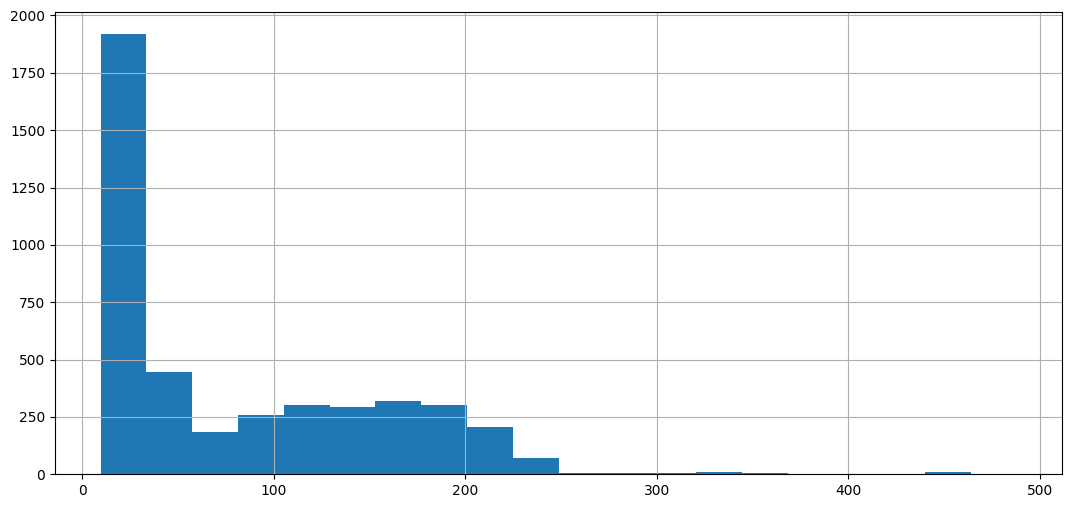

In [69]:
Consumer_Price_Index_Data['cpi'].hist(bins=20,figsize=(13,6))

### There is need to outlier treatment

In [70]:
Consumer_Price_Index_Data.nunique()

stateFips                   2
area                        2
areaType                    2
periodYear                102
periodType                  3
periodTypeDescription       3
cpi                      1639
title                      13
type                       13
percentChangeYear         293
percentChangeMonth        113
areaName                    2
areaDescription             2
dtype: int64

In [71]:
Consumer_Price_Index_Data.columns

Index(['stateFips', 'area', 'areaType', 'periodYear', 'periodType',
       'periodTypeDescription', 'cpi', 'title', 'type', 'percentChangeYear',
       'percentChangeMonth', 'areaName', 'areaDescription'],
      dtype='str')

## categoricalColumns:['stateFips', 'area', 'areaType', 'periodYear', 'periodType','periodTypeDescription','title','type','areaName','areaDescription']
## continousColumns:['cpi','percentChangeYear', 'percentChangeMonth'] 

In [72]:
Consumer_Price_Index_Data.head(2)

,stateFips,area,areaType,periodYear,periodType,periodTypeDescription,cpi,title,type,percentChangeYear,percentChangeMonth,areaName,areaDescription
0,0,0,0,1913,1,Annual,9.9,"CPI-U all items 1982-84=100, not seasonally ad...",1,0.0,0.0,United States,The United States of America
1,0,0,0,1913,1,Annual,10.0,"CPI-W all items 1982-84=100, not seasonally ad...",3,0.0,0.0,United States,The United States of America


In [73]:
Consumer_Price_Index_Data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   stateFips              4349 non-null   int64  
 1   area                   4349 non-null   int64  
 2   areaType               4349 non-null   int64  
 3   periodYear             4349 non-null   int64  
 4   periodType             4349 non-null   int64  
 5   periodTypeDescription  4349 non-null   str    
 6   cpi                    4349 non-null   float64
 7   title                  4349 non-null   str    
 8   type                   4349 non-null   int64  
 9   percentChangeYear      4349 non-null   float64
 10  percentChangeMonth     4131 non-null   float64
 11  areaName               4349 non-null   str    
 12  areaDescription        4349 non-null   str    
dtypes: float64(3), int64(6), str(4)
memory usage: 854.9 KB


In [74]:
Consumer_Price_Index_Data.describe()

,stateFips,area,areaType,periodYear,periodType,cpi,type,percentChangeYear,percentChangeMonth
count,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4349.000000,4131.000000
mean,0.467234,0.116808,1.401702,1970.362382,3.030352,83.272986,4.733042,3.415797,0.269354
std,1.876266,0.469066,5.628797,27.354856,0.942212,73.970614,11.064200,4.430625,1.060419
min,0.000000,0.000000,0.000000,1913.000000,1.000000,9.700000,1.000000,-15.800000,-8.600000
25%,0.000000,0.000000,0.000000,1951.000000,3.000000,25.500000,1.000000,1.300000,0.000000
50%,0.000000,0.000000,0.000000,1972.000000,3.000000,42.400000,3.000000,2.900000,0.200000
75%,0.000000,0.000000,0.000000,1994.000000,3.000000,142.600000,3.000000,4.700000,0.500000
max,8.000000,2.000000,24.000000,2014.000000,7.000000,487.877000,59.000000,23.700000,11.200000


### Uni Variate Analysis by Histogram

array([[<Axes: title={'center': 'cpi'}>,
        <Axes: title={'center': 'percentChangeYear'}>],
       [<Axes: title={'center': 'percentChangeMonth'}>,
        <Axes: title={'center': 'periodYear'}>]], dtype=object)

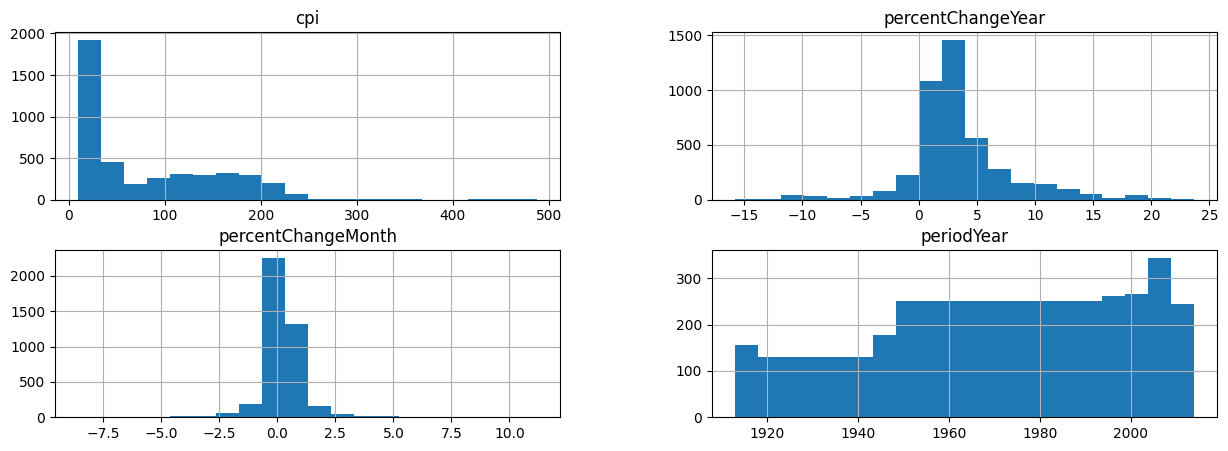

In [75]:
continousColumns=['cpi','percentChangeYear', 'percentChangeMonth','periodYear']
Consumer_Price_Index_Data[continousColumns].hist(bins=20,figsize=(15,5))

## Outlier Treatment

In [16]:
Consumer_Price_Index_Data['cpi'][Consumer_Price_Index_Data['cpi']<400].sort_values(ascending=False).head(15)

1772    388.400
1593    378.200
1691    367.900
1407    359.100
1203    352.100
4348    351.975
4342    347.953
1309    345.100
4332    341.039
4294    338.000
4321    335.800
4304    333.700
4276    333.100
4314    331.600
4285    328.200
Name: cpi, dtype: float64

In [17]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['cpi']>400,'cpi']=388.400

<Axes: >

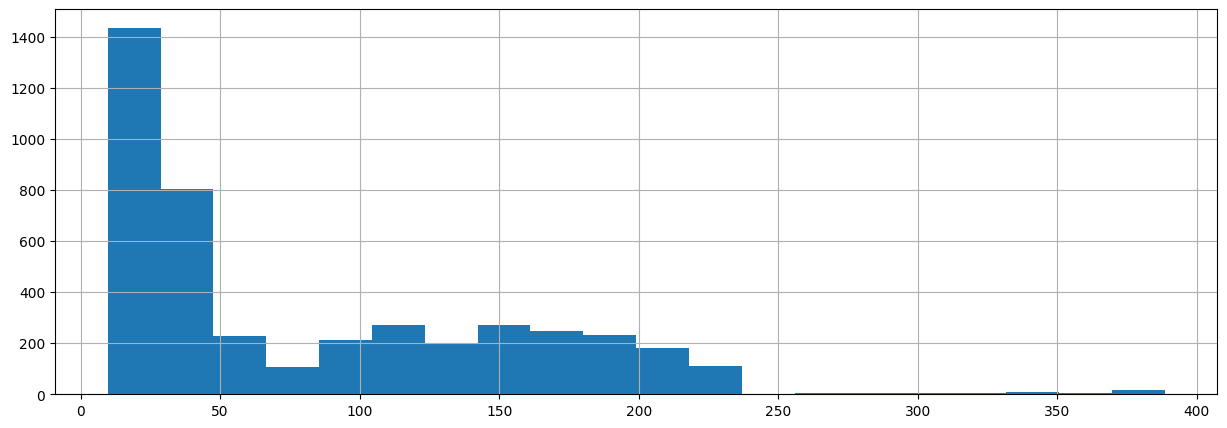

In [18]:
Consumer_Price_Index_Data['cpi'].hist(bins=20,figsize=(15,5))

## Uni Variate Analysis by Bar Charts

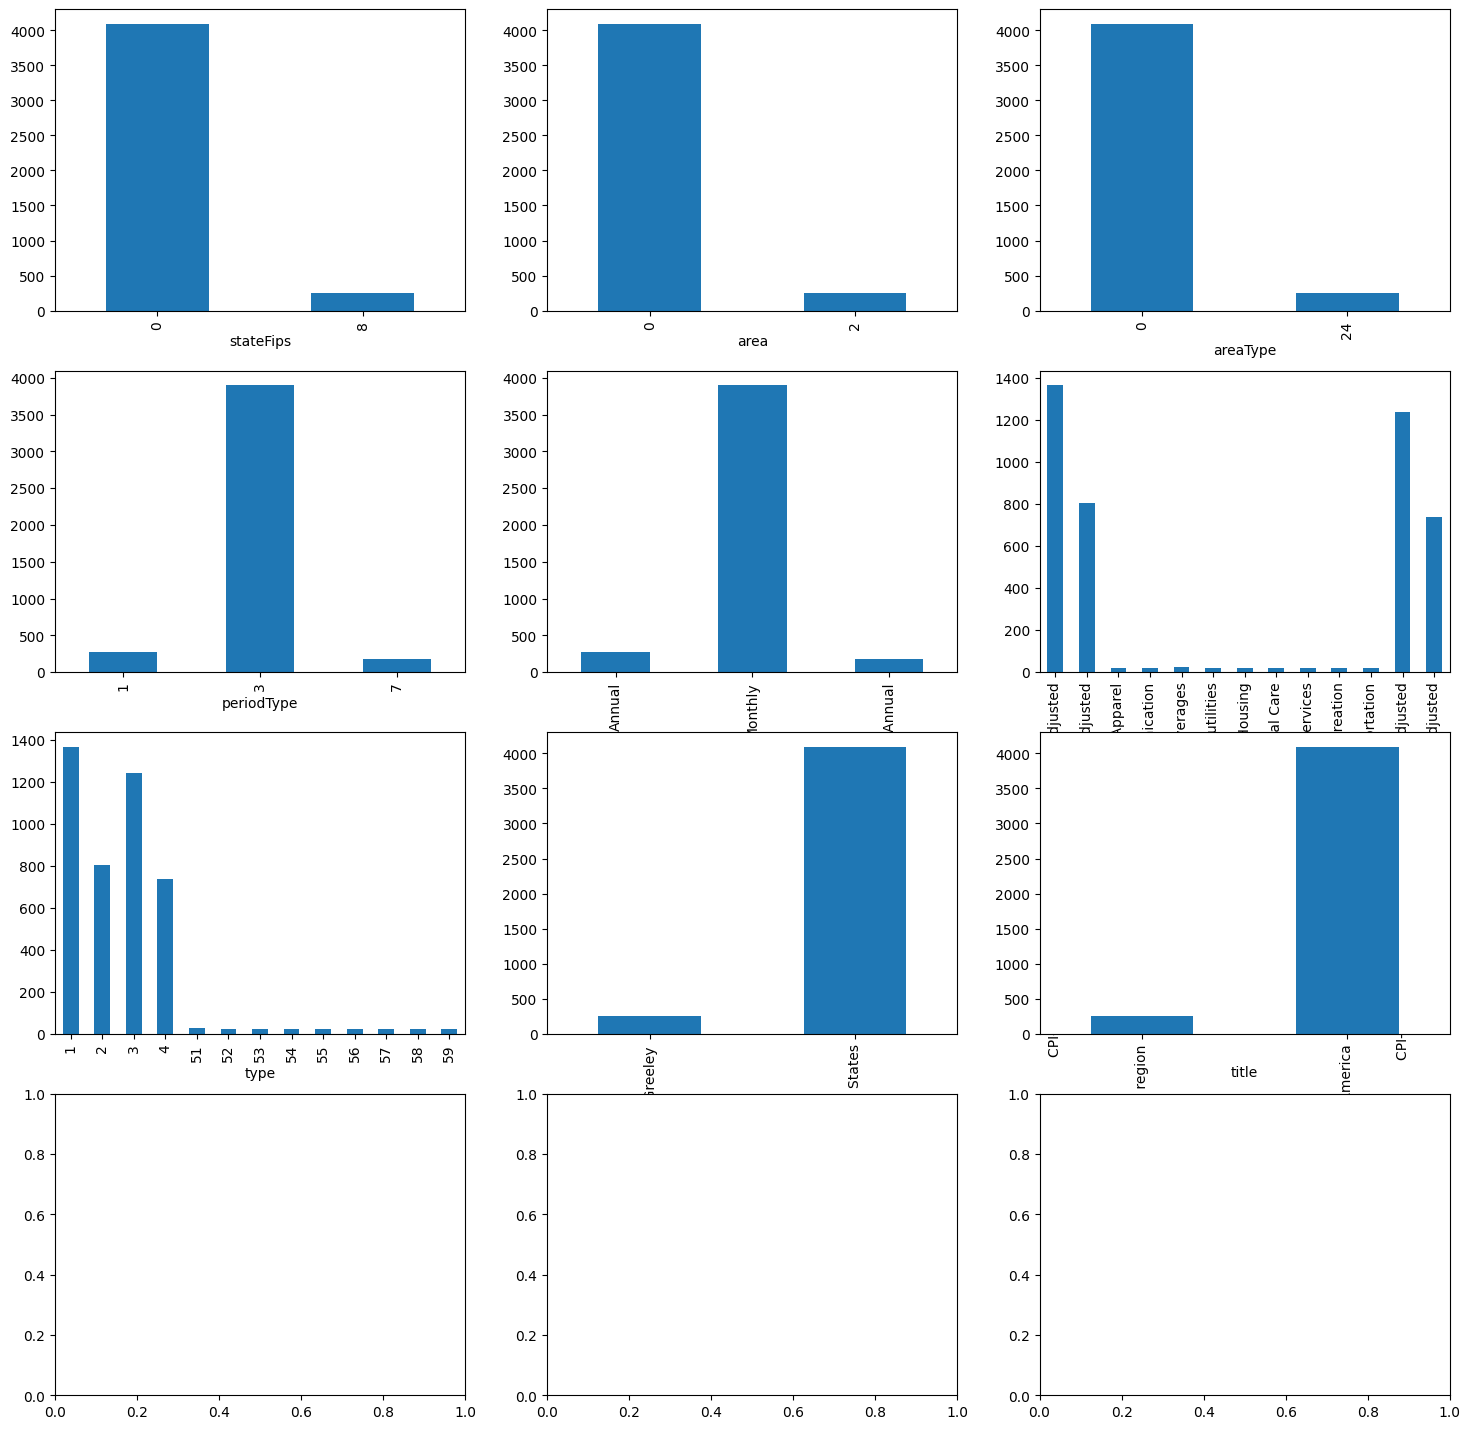

In [76]:
categoricalColumns=['stateFips', 'area', 'areaType', 'periodType','periodTypeDescription','title','type','areaName','areaDescription']
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(4,3,figsize=(18,18))
subplots=subplots.flatten()
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Consumer_Price_Index_Data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

If Accuracy of model is not getting jnto required limit then eliminate this columns as these are not good for Machine Learning:['stateFips', 'area', 'areaType','areaName']

## Imbalance Treatment

In [20]:
Consumer_Price_Index_Data['type']=Consumer_Price_Index_Data['type'].astype(str)


In [21]:
Consumer_Price_Index_Data['periodType']=Consumer_Price_Index_Data['periodType'].astype(str)

In [22]:
Consumer_Price_Index_Data['periodType'].info()

<class 'pandas.Series'>
RangeIndex: 4349 entries, 0 to 4348
Series name: periodType
Non-Null Count  Dtype
--------------  -----
4349 non-null   str  
dtypes: str(1)
memory usage: 38.4 KB


In [23]:
Consumer_Price_Index_Data['periodType'].unique()

<ArrowStringArray>
['1', '3', '7']
Length: 3, dtype: str

In [24]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['periodType'].isin(['1','7']),'periodType']='Others'
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['periodTypeDescription']=='Semi-Annual','periodTypeDescription']='Annual'
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['title'].isin(['CPI-U:  Transportation','CPI-U:  Recreation','CPI-U:  Other goods and services',
     'CPI-U:  Medical Care','CPI-U:  Housing','CPI-U:  Fuels and utilities','CPI-U:  Food and beverages','CPI-U:  Education and communication',
    'CPI-U:  Apparel']),'title']='Others'
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['type'].isin([ '51','52', '53', '54', '55', '56', '57', '58', '59']),'type']='>51' 

<Axes: ylabel='title'>

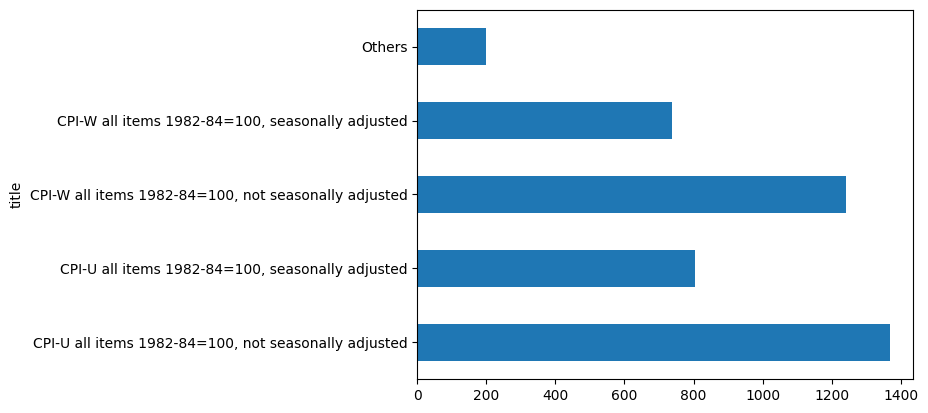

In [25]:
Consumer_Price_Index_Data.groupby('title').size().plot(kind='barh')

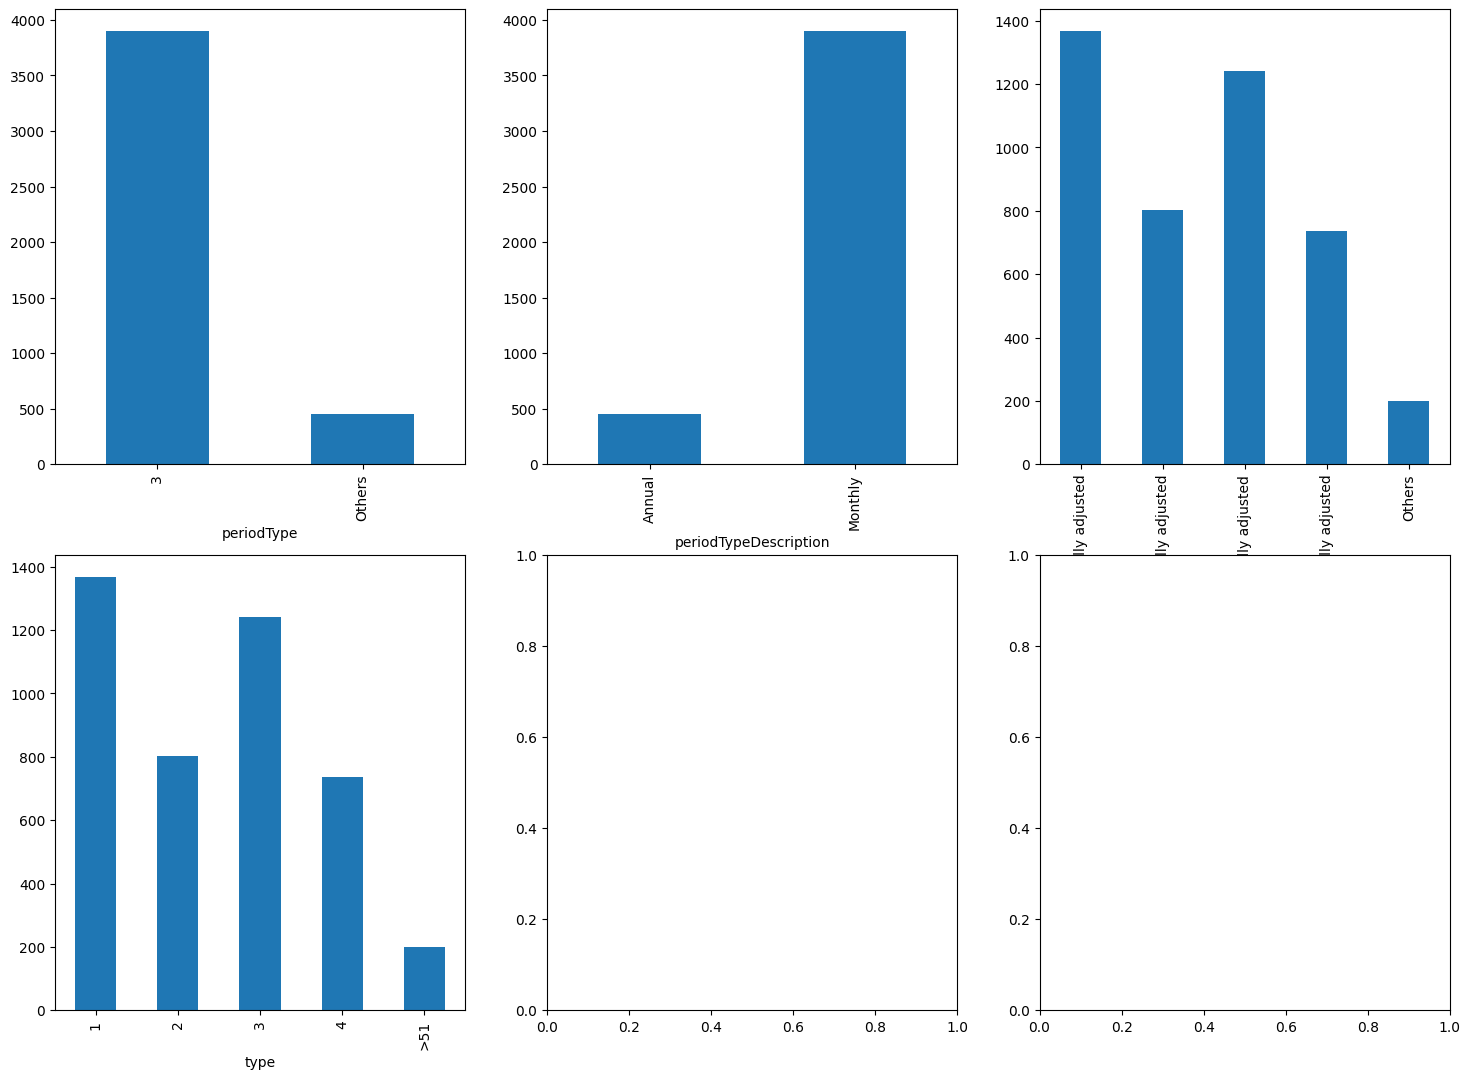

In [26]:
categoricalColumns=[ 'periodType','periodTypeDescription','title','type']
import matplotlib.pyplot as plt 
fig,subplots=plt.subplots(2,3,figsize=(18,13))
subplots=subplots.flatten()
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Consumer_Price_Index_Data.groupby(cols).size().plot(kind='bar',ax=subplots[no_of_cols])

## Missing Value Treatment:

In [27]:
Consumer_Price_Index_Data.isnull().sum() 

stateFips                  0
area                       0
areaType                   0
periodYear                 0
periodType                 0
periodTypeDescription      0
cpi                        0
title                      0
type                       0
percentChangeYear          0
percentChangeMonth       218
areaName                   0
areaDescription            0
dtype: int64

In [28]:
Consumer_Price_Index_Data['percentChangeMonth'].median()

0.2

In [29]:
Consumer_Price_Index_Data.loc[Consumer_Price_Index_Data['percentChangeMonth'].isnull(),'percentChangeMonth']=0.2

In [30]:
Consumer_Price_Index_Data.isnull().sum() 

stateFips                0
area                     0
areaType                 0
periodYear               0
periodType               0
periodTypeDescription    0
cpi                      0
title                    0
type                     0
percentChangeYear        0
percentChangeMonth       0
areaName                 0
areaDescription          0
dtype: int64

## Continuous Vs Continuous -- Scatter Charts

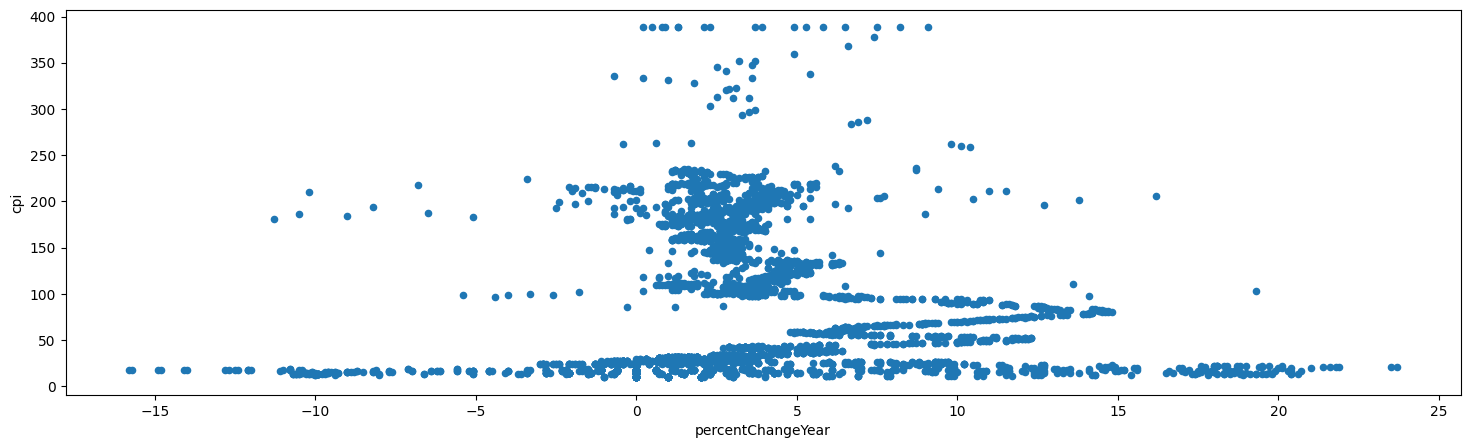

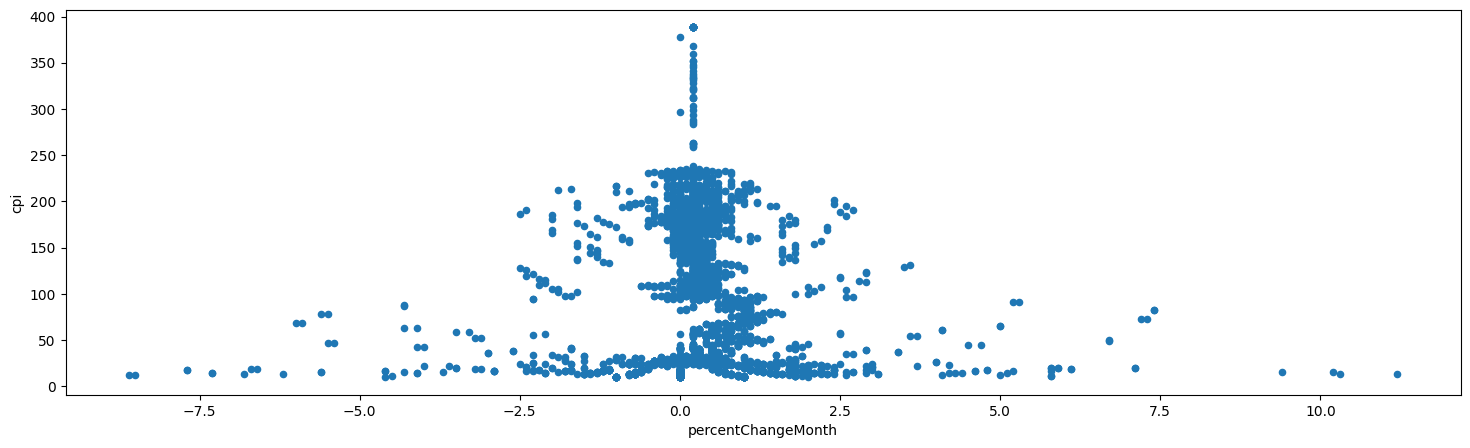

In [31]:
continousColumns=['percentChangeYear', 'percentChangeMonth']
for l in continousColumns:
    Consumer_Price_Index_Data.plot.scatter(x=l,y='cpi',figsize=(18,5))

### No clear Trend is getting

## Statistical Feature Selection (Continuous Vs Continuous) using Correlation value

In [32]:
continousColumns=['cpi','percentChangeYear', 'percentChangeMonth']
correaltionData=Consumer_Price_Index_Data[continousColumns].corr()
correaltionData

,cpi,percentChangeYear,percentChangeMonth
cpi,1.000000,0.000537,-0.004361
percentChangeYear,0.000537,1.000000,0.308690
percentChangeMonth,-0.004361,0.308690,1.000000


### There is not high correlation with cpi

## Categorical Vs Continuous -- Box Plots

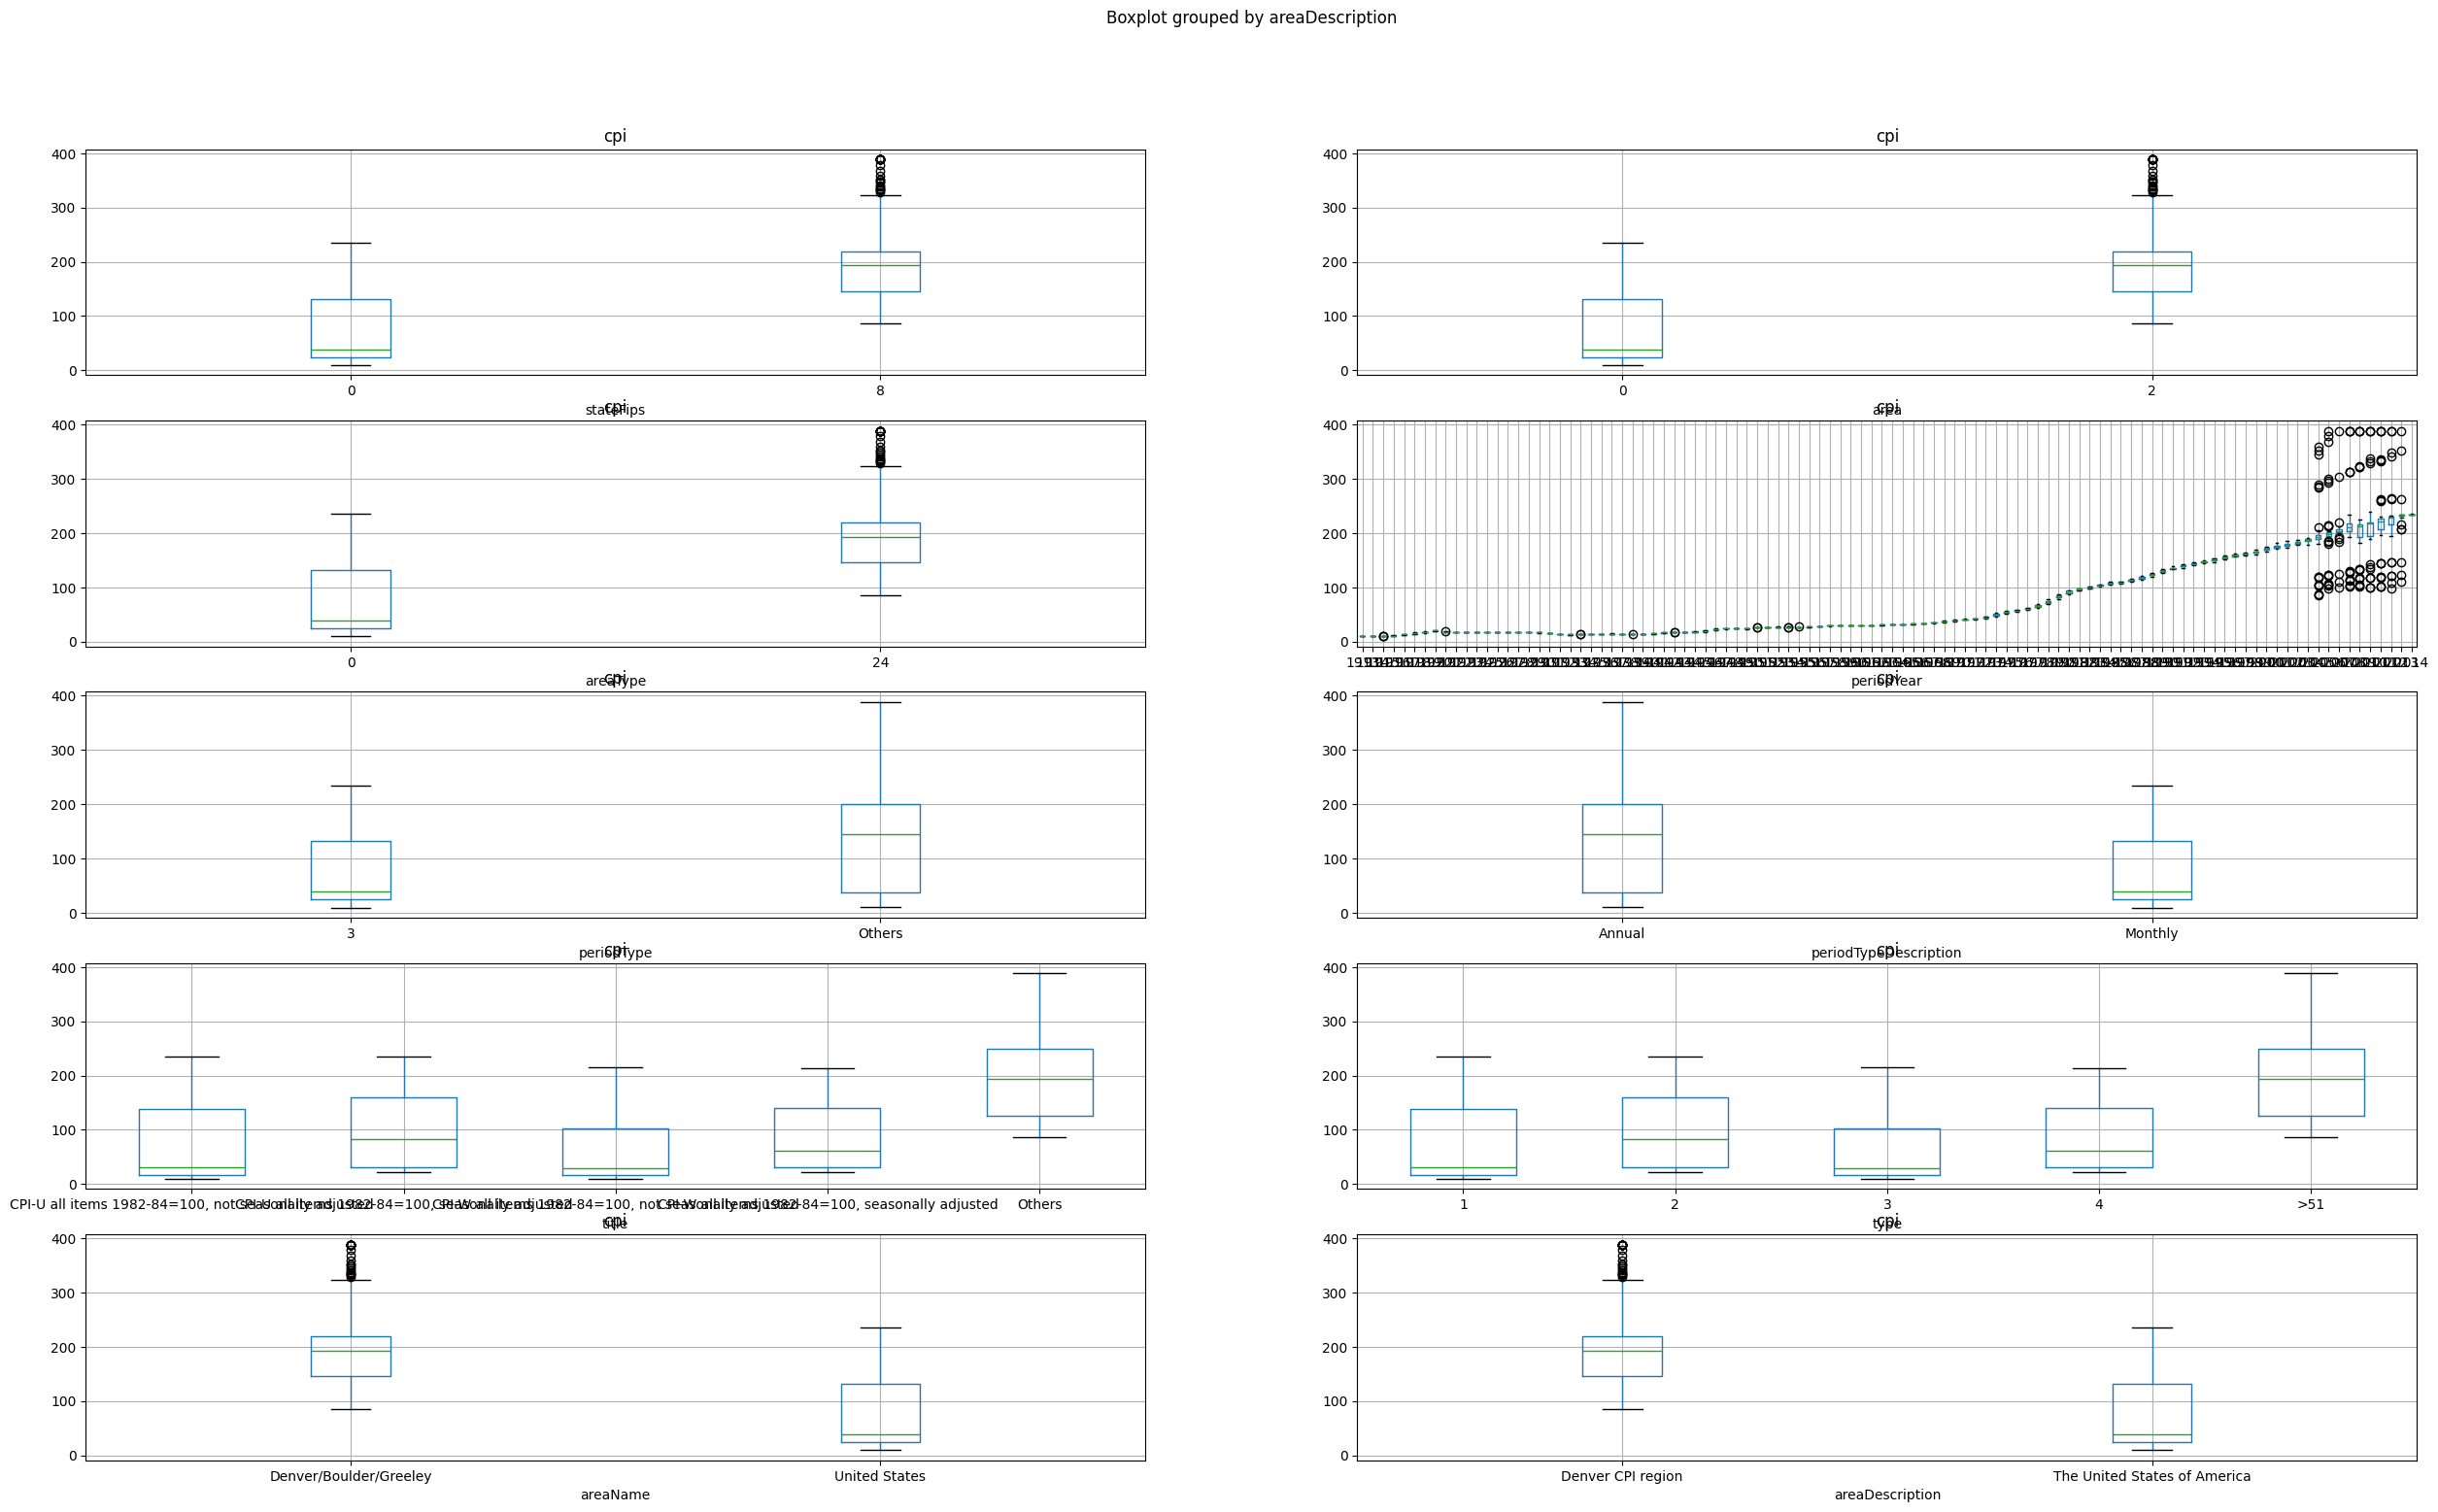

In [33]:
categoricalColumns=['stateFips', 'area', 'areaType', 'periodYear', 'periodType','periodTypeDescription','title','type','areaName','areaDescription']  
import matplotlib.pyplot as plt
fig,subplots=plt.subplots(5,2,figsize=(30,18))
subplots=subplots.flatten() 
for cols, no_of_cols in zip(categoricalColumns,range(len(categoricalColumns))):
    Consumer_Price_Index_Data.boxplot(column='cpi',by=cols,vert=True,ax=subplots[no_of_cols])

## Statistical Feature Selection (Categorical Vs Continuous) using ANOVA test

In [79]:
categoricalColumns=['stateFips', 'area', 'areaType', 'periodYear', 'periodType','periodTypeDescription','title','type','areaName','areaDescription'] 
def functionAnova(inpData,categoricalColumns,targetVariable):
    from scipy.stats import f_oneway
    SelectedPredictors=[] 
    for cols in categoricalColumns:
        CategoricalGroupLists=Consumer_Price_Index_Data.groupby(cols)[targetVariable].apply(list)
        AnovaResults=f_oneway(*CategoricalGroupLists)
        if AnovaResults[1]<0.05:
            print(cols,' is  correlated with cpi and P value is:',AnovaResults[1])
            SelectedPredictors.append(cols)
        else:
            print(cols,' is not correlated with cpi and P value is:',AnovaResults[1])
    return SelectedPredictors
functionAnova(Consumer_Price_Index_Data,categoricalColumns,'cpi')

stateFips  is  correlated with cpi and P value is: 3.8757705043475727e-181
area  is  correlated with cpi and P value is: 3.8757705043475727e-181
areaType  is  correlated with cpi and P value is: 3.8757705043475727e-181
periodYear  is  correlated with cpi and P value is: 0.0
periodType  is  correlated with cpi and P value is: 3.11434959263667e-129
periodTypeDescription  is  correlated with cpi and P value is: 3.11434959263667e-129
title  is  correlated with cpi and P value is: 1.5259630754159782e-267
type  is  correlated with cpi and P value is: 1.5259630754156313e-267
areaName  is  correlated with cpi and P value is: 3.8757705043475727e-181
areaDescription  is  correlated with cpi and P value is: 3.8757705043475727e-181


['stateFips',
 'area',
 'areaType',
 'periodYear',
 'periodType',
 'periodTypeDescription',
 'title',
 'type',
 'areaName',
 'areaDescription']

### All Categorical Columns are correlated with target variable.

In [35]:
SelectedColumns=['stateFips',
 'area',
 'areaType',
 'periodYear',
 'periodType',
 'periodTypeDescription',
 'title',
 'type',
 'areaName',
 'areaDescription','percentChangeYear', 'percentChangeMonth']
DataForML=Consumer_Price_Index_Data[SelectedColumns]
DataForML.to_pickle('DataForMLConsumer_Price_Index_Data.pkl')
DataForMLConsumer_Price_Index_Data=pd.read_pickle('DataForMLConsumer_Price_Index_Data.pkl')
DataForMLConsumer_Price_Index_Data.head()

,stateFips,area,areaType,periodYear,periodType,periodTypeDescription,title,type,areaName,areaDescription,percentChangeYear,percentChangeMonth
0,0,0,0,1913,Others,Annual,"CPI-U all items 1982-84=100, not seasonally ad...",1,United States,The United States of America,0.0,0.0
1,0,0,0,1913,Others,Annual,"CPI-W all items 1982-84=100, not seasonally ad...",3,United States,The United States of America,0.0,0.0
2,0,0,0,1913,3,Monthly,"CPI-U all items 1982-84=100, not seasonally ad...",1,United States,The United States of America,0.0,-1.0
3,0,0,0,1913,3,Monthly,"CPI-W all items 1982-84=100, not seasonally ad...",3,United States,The United States of America,0.0,-1.0
4,0,0,0,1913,3,Monthly,"CPI-U all items 1982-84=100, not seasonally ad...",1,United States,The United States of America,0.0,0.0


## Data Preprocessing for Machine Learning

In [36]:
pd.set_option('display.max_columns',None)

In [37]:
DataForMLConsumer_Price_Index_Data_Numeric=pd.get_dummies(DataForMLConsumer_Price_Index_Data)
DataForMLConsumer_Price_Index_Data_Numeric.replace({True:1,False:0},inplace=True)
DataForMLConsumer_Price_Index_Data_Numeric.head()

,stateFips,area,areaType,periodYear,percentChangeYear,percentChangeMonth,periodType_3,periodType_Others,periodTypeDescription_Annual,periodTypeDescription_Monthly,"title_CPI-U all items 1982-84=100, not seasonally adjusted","title_CPI-U all items 1982-84=100, seasonally adjusted","title_CPI-W all items 1982-84=100, not seasonally adjusted","title_CPI-W all items 1982-84=100, seasonally adjusted",title_Others,type_1,type_2,type_3,type_4,type_>51,areaName_Denver/Boulder/Greeley,areaName_United States,areaDescription_Denver CPI region,areaDescription_The United States of America
0,0,0,0,1913,0.0,0.0,0,1,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,1
1,0,0,0,1913,0.0,0.0,0,1,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1
2,0,0,0,1913,0.0,-1.0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1
3,0,0,0,1913,0.0,-1.0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,1
4,0,0,0,1913,0.0,0.0,1,0,0,1,1,0,0,0,0,1,0,0,0,0,0,1,0,1


In [38]:
DataForMLConsumer_Price_Index_Data_Numeric=(DataForMLConsumer_Price_Index_Data_Numeric.apply(pd.to_numeric))

In [39]:
DataForMLConsumer_Price_Index_Data_Numeric.info()

<class 'pandas.DataFrame'>
RangeIndex: 4349 entries, 0 to 4348
Data columns (total 24 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   stateFips                                                   4349 non-null   int64  
 1   area                                                        4349 non-null   int64  
 2   areaType                                                    4349 non-null   int64  
 3   periodYear                                                  4349 non-null   int64  
 4   percentChangeYear                                           4349 non-null   float64
 5   percentChangeMonth                                          4349 non-null   float64
 6   periodType_3                                                4349 non-null   int64  
 7   periodType_Others                                           4349 non-null   int64  
 8   periodTyp

In [40]:
DataForMLConsumer_Price_Index_Data_Numeric.columns

Index(['stateFips', 'area', 'areaType', 'periodYear', 'percentChangeYear',
       'percentChangeMonth', 'periodType_3', 'periodType_Others',
       'periodTypeDescription_Annual', 'periodTypeDescription_Monthly',
       'title_CPI-U all items 1982-84=100, not seasonally adjusted',
       'title_CPI-U all items 1982-84=100, seasonally adjusted',
       'title_CPI-W all items 1982-84=100, not seasonally adjusted',
       'title_CPI-W all items 1982-84=100, seasonally adjusted',
       'title_Others', 'type_1', 'type_2', 'type_3', 'type_4', 'type_>51',
       'areaName_Denver/Boulder/Greeley', 'areaName_United States',
       'areaDescription_Denver CPI region',
       'areaDescription_The United States of America'],
      dtype='str')

In [41]:
DataForMLConsumer_Price_Index_Data_Numeric['cpi']=Consumer_Price_Index_Data['cpi']
targetVariable='cpi'
predictors=['stateFips', 'area', 'areaType', 'periodYear', 'percentChangeYear',
       'percentChangeMonth', 'periodType_3', 'periodType_Others',
       'periodTypeDescription_Annual', 'periodTypeDescription_Monthly',
       'title_CPI-U all items 1982-84=100, not seasonally adjusted',
       'title_CPI-U all items 1982-84=100, seasonally adjusted',
       'title_CPI-W all items 1982-84=100, not seasonally adjusted',
       'title_CPI-W all items 1982-84=100, seasonally adjusted',
       'title_Others', 'type_1', 'type_2', 'type_3', 'type_4', 'type_>51',
       'areaName_Denver/Boulder/Greeley', 'areaName_United States',
       'areaDescription_Denver CPI region',
       'areaDescription_The United States of America']
predictors=[ 'periodYear', 'percentChangeYear']
X=DataForMLConsumer_Price_Index_Data_Numeric[predictors].values
y=DataForMLConsumer_Price_Index_Data_Numeric[targetVariable].values

# Polynomial Regression
#from sklearn.preprocessing import PolynomialFeatures
#poly=PolynomialFeatures(degree=2, include_bias=False)
#X=poly.fit_transform(X) 
#predictors=poly.get_feature_names_out()


from sklearn.model_selection import train_test_split
X_train, X_test,y_train,y_test=train_test_split(X,y,random_state=45,test_size=0.2)
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(3479, 2)
(3479,)
(870, 2)
(870,)


In [42]:
X_train[0:5]

array([[1.969e+03, 5.500e+00],
       [1.915e+03, 1.000e+00],
       [1.991e+03, 2.800e+00],
       [1.981e+03, 9.800e+00],
       [1.984e+03, 4.800e+00]])

In [43]:
y_train[0:5]

array([ 36.6,  10.1, 137.2,  89.7, 102.6])

## Linear Regression

In [44]:
from sklearn.linear_model import LinearRegression
RegModel=LinearRegression()
LREG=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round((metrics.r2_score(y_train,LREG.predict(X_train))*100),2),'%')
prediction=LREG.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults['Predicted'+targetVariable]=prediction
TestingDataResults[targetVariable]=y_test
# TestingDataResults.head() 
TestingDataResults['APE']= (abs(TestingDataResults[targetVariable]-TestingDataResults['Predicted'+targetVariable])/TestingDataResults[targetVariable])*100
# (TestingDataResults[['Predicted'+targetVariable,targetVariable,'APE']]).head(5)
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)

def accuracy_Score(orig,pred):
    MAPE=np.mean((abs(orig-pred)/orig)*100)
    return 100-MAPE

from sklearn.metrics import make_scorer
custom_scoring=make_scorer(accuracy_Score,greater_is_better=True)

from sklearn.model_selection import cross_val_score
Accuracy_Values=cross_val_score(LREG,X,y,cv=5,scoring=custom_scoring)
print(Accuracy_Values)
print(np.mean(Accuracy_Values))

R2 Value: 76.73 %
23.658722775321294
61.17685972304609
[-497.13715423   11.06359141  -21.07473872   91.06722873   68.31348729]
-69.55351710398915


R2 Value: 0.946
96.90326976076427
98.8030888030888
[73.00777004 80.50806054 73.08335577 78.0384342  80.19413231]
Final Accuracy of the Model: 76.97 %


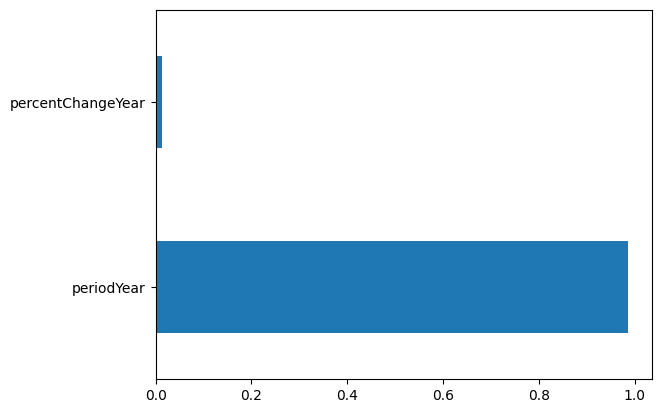

In [45]:
from sklearn.tree import DecisionTreeRegressor
RegModel=DecisionTreeRegressor(max_depth=7,criterion='squared_error')
DT=RegModel.fit(X_train,y_train)
from sklearn import metrics
print('R2 Value:',np.round(metrics.r2_score(y_train,DT.predict(X_train)),3))

feature_importances=pd.Series(DT.feature_importances_,index=predictors)
feature_importances.nlargest(10).plot(kind='barh')

prediction=DT.predict(X_test)
TestingDataResults=pd.DataFrame(X_test,columns=predictors)
TestingDataResults['Predicted'+targetVariable]=prediction
TestingDataResults[targetVariable]=y_test
# TestingDataResults.head()
TestingDataResults['APE']= (abs(TestingDataResults[targetVariable]-TestingDataResults['Predicted'+targetVariable])/TestingDataResults[targetVariable])*100
# (TestingDataResults[['Predicted'+targetVariable,targetVariable,'APE']]).head(5)
MAPE=np.mean(TestingDataResults['APE'])
MedianAPE=np.median(TestingDataResults['APE'])
MeanAccuracy=100-MAPE
MedianAccuracy=100-MedianAPE
print(MeanAccuracy)
print(MedianAccuracy)

def accuracy_Score(orig,pred):
    MAPE=np.mean((abs(orig-pred)/orig)*100)
    return 100-MAPE

from sklearn.metrics import make_scorer
custom_scoring=make_scorer(accuracy_Score,greater_is_better=True)

from sklearn.model_selection import cross_val_score
Accuracy_Values=cross_val_score(DT,X,y,cv=5,scoring=custom_scoring)
print(Accuracy_Values)
print('Final Accuracy of the Model:',np.round(np.mean(Accuracy_Values),2),'%')

# Model Deployment on Sample Data

In [46]:
NewData=pd.DataFrame(data=[[1994,0.35],
                          [1997,3.56],
                          [2001,4.5]],columns=predictors)
NewData

,periodYear,percentChangeYear
0,1994,0.35
1,1997,3.56
2,2001,4.50


In [47]:
newX=NewData.values

In [48]:
DT.predict(newX)

array([145.61818182, 158.99555556, 175.88378378])

In [49]:
def GeneratePred(inpData):
    newX=NewData.values
    pred=DT.predict(newX)
    inpData['Prediction']=pred
    return (inpData) 

In [50]:
GeneratePred(inpData=NewData)

,periodYear,percentChangeYear,Prediction
0,1994,0.35,145.618182
1,1997,3.56,158.995556
2,2001,4.50,175.883784


In [51]:
np.random.seed(45)
NewData=pd.DataFrame()
NewData['periodYear']=np.random.randint(1990,2010,100)
NewData['percentChangeYear']=np.round(np.random.uniform(0,10,100),2)

NewData.head()

,periodYear,percentChangeYear
0,2001,5.62
1,1993,0.35
2,1990,0.23
3,1993,5.12
4,1994,5.21


In [52]:
def GeneratePred(inpData):
    NewX=inpData.values
    pred=DT.predict(NewX)
    inpData['Predictions']=pred
    return inpData
GeneratePred(inpData=NewData)

,periodYear,percentChangeYear,Predictions
0,2001,5.62,175.883784
1,1993,0.35,143.846154
2,1990,0.23,128.173077
3,1993,5.12,142.100000
4,1994,5.21,148.270000
5,2005,7.30,288.400000
6,1991,2.66,136.442857
7,2004,3.45,184.670248
8,1998,8.09,161.395349
9,2004,6.58,284.200000
